数据生成

使用 sklearn.datasets.make_moons 生成 2000 个样本，噪声 noise=0.2，随机状态 random_state=0。

将数据集按 80%/20% 划分为训练集和验证集。

网络结构

输入层：2 个神经元（对应 2 维输入）。

隐藏层 1：16 个神经元，ReLU 激活。

隐藏层 2：16 个神经元，ReLU 激活，随后添加 Dropout（丢弃率 0.5）。

隐藏层 3：8 个神经元，ReLU 激活。

输出层：2 个神经元，输出 logits（不显式加 softmax，由 nn.CrossEntropyLoss 处理）。

训练配置

损失函数：nn.CrossEntropyLoss()

优化器：Adam，学习率 lr=0.001

训练轮数：500

每个 epoch 记录训练集和验证集的 loss，并绘制 loss 曲线。

训练结束后，用验证集计算分类准确率，并绘制决策边界（可选）。

提交内容

完整的模型定义与前向、反向推导代码

训练日志（每隔若干 epoch 打印一次 loss）

最终验证集准确率

loss 曲线图（训练 & 验证）

（可选）在二维平面上绘制 make_moons 样本及模型的决策边界

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import sklearn
import numpy as np
from sklearn.metrics import confusion_matrix
import seaborn as sns

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [3]:
class SimpleNN(nn.Module):
  def __init__(self):
    super().__init__()
    self.layer1 = nn.Linear(2, 16)
    self.layer2 = nn.Linear(16, 16)
    self.dropout2 = nn.Dropout(p=0.5)

    self.layer3 = nn.Linear(16, 8)
    self.output = nn.Linear(8, 2)

  def forward(self, x):
    x = torch.relu(self.layer1(x))
    x = torch.relu(self.layer2(x))
    x = self.dropout2(x)

    x = torch.relu(self.layer3(x))
    x = self.output(x)
    return x


epoch: 1 train_loss:0.6924, test_loss:0.6812
epoch: 11 train_loss:0.5643, test_loss:0.5372
epoch: 21 train_loss:0.3857, test_loss:0.3534
epoch: 31 train_loss:0.2935, test_loss:0.2517
epoch: 41 train_loss:0.2257, test_loss:0.1918
epoch: 51 train_loss:0.1788, test_loss:0.1354
epoch: 61 train_loss:0.1417, test_loss:0.1048
epoch: 71 train_loss:0.1256, test_loss:0.0953
epoch: 81 train_loss:0.1051, test_loss:0.0900
epoch: 91 train_loss:0.1019, test_loss:0.0890
epoch: 101 train_loss:0.1078, test_loss:0.0918
epoch: 111 train_loss:0.0912, test_loss:0.0917
epoch: 121 train_loss:0.0871, test_loss:0.1011
epoch: 131 train_loss:0.0888, test_loss:0.0925
epoch: 141 train_loss:0.0941, test_loss:0.0912
epoch: 151 train_loss:0.0889, test_loss:0.1075
epoch: 161 train_loss:0.0843, test_loss:0.0979
epoch: 171 train_loss:0.0823, test_loss:0.0982
epoch: 181 train_loss:0.0845, test_loss:0.0979
epoch: 191 train_loss:0.0756, test_loss:0.0998
epoch: 201 train_loss:0.0866, test_loss:0.0948
epoch: 211 train_loss:0.

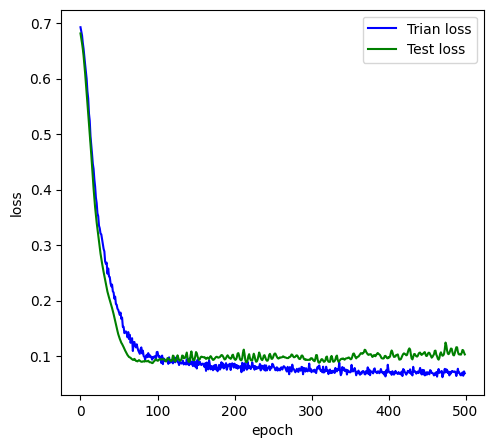

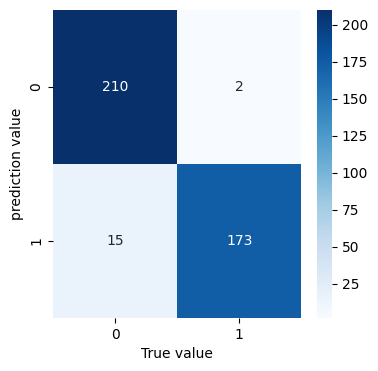

In [5]:
sample_num = 2000

x, y = sklearn.datasets.make_moons(
    n_samples = sample_num,    # 样本总数
    shuffle=True,          # 是否打乱顺序
    noise=0.2,          # 加入高斯噪声的标准差
    random_state=0        # 随机种子
)

model = SimpleNN().to(device)

epochs = 500
losses = []

train_size = int(sample_num*0.8)
x_train = torch.tensor(x[:train_size], dtype=torch.float32).to(device)
y_train = torch.tensor(y[:train_size], dtype=torch.int64).to(device)

x_test = torch.tensor(x[train_size:], dtype=torch.float32).to(device)
y_test = torch.tensor(y[train_size:], dtype=torch.int64).to(device)

train_losses = []
test_losses = []

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.01)

for epoch in range(epochs):
  model.train()
  y_pred_train = model(x_train)

  train_loss = criterion(y_pred_train, y_train)
  train_losses.append(train_loss.item())

  optimizer.zero_grad()
  train_loss.backward()
  optimizer.step()

  model.eval()
  with torch.no_grad():
    y_pred_test = model(x_test)

    test_loss = criterion(y_pred_test, y_test)
    test_losses.append(test_loss.item())

  if epoch%10 == 0:
    print(f"epoch: {epoch + 1}",
      f"train_loss:{train_loss.item():.4f}, test_loss:{test_loss.item():.4f}")

plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.plot(range(epochs), train_losses, label="Trian loss", color="blue")
plt.plot(range(epochs), test_losses, label="Test loss", color="green")
plt.xlabel("epoch")
plt.ylabel("loss")
plt.legend()

model.eval()
with torch.no_grad():
  y_pred_test = model(x_test).cpu().numpy()
  y_pred_label = np.argmax(y_pred_test, axis=1)
  y_test_np = y_test.cpu().numpy()

cm = confusion_matrix(y_test_np, y_pred_label)
plt.figure(figsize=(4,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("True value")
plt.ylabel("prediction value")

plt.show()